In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        
    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            attn_scores = attn_scores.masked_fill(mask == 0, -1e9)
        attn_probs = torch.softmax(attn_scores, dim=-1)
        output = torch.matmul(attn_probs, V)
        return output
        
    def forward(self, query, key, value, mask=None):
        batch_size = query.size(0)
        
        Q = self.W_q(query)
        K = self.W_k(key)
        V = self.W_v(value)
        
        Q = Q.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = K.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        
        attn_output = self.scaled_dot_product_attention(Q, K, V, mask)
        
        attn_output = attn_output.transpose(1, 2).contiguous().view(
            batch_size, -1, self.d_model)
        
        output = self.W_o(attn_output)
        return output

class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PositionwiseFeedForward, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        
    def forward(self, x):
        return self.fc2(F.relu(self.fc1(x)))

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_length=5000):
        super(PositionalEncoding, self).__init__()
        
        pe = torch.zeros(max_seq_length, d_model)
        position = torch.arange(0, max_seq_length, dtype=torch.float).unsqueeze(1)
        
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * 
                           -(math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        self.register_buffer('pe', pe.unsqueeze(0))
        
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionwiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, mask):
        attn_output = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_output))
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))
        return x

class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionwiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, enc_output, src_mask, tgt_mask):
        attn_output = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(attn_output))
        attn_output = self.cross_attn(x, enc_output, enc_output, src_mask)
        x = self.norm2(x + self.dropout(attn_output))
        ff_output = self.feed_forward(x)
        x = self.norm3(x + self.dropout(ff_output))
        return x

class Transformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model, num_heads, 
                 num_layers, d_ff, max_seq_length, dropout):
        super(Transformer, self).__init__()
        self.encoder_embedding = nn.Embedding(src_vocab_size, d_model)
        self.decoder_embedding = nn.Embedding(tgt_vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model, max_seq_length)
        
        self.encoder_layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout) 
            for _ in range(num_layers)
        ])
        
        self.decoder_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, dropout) 
            for _ in range(num_layers)
        ])
        
        self.fc = nn.Linear(d_model, tgt_vocab_size)
        self.dropout = nn.Dropout(dropout)
        
    def generate_mask(self, src, tgt):
        src_mask = (src != 0).unsqueeze(1).unsqueeze(2)
        tgt_mask = (tgt != 0).unsqueeze(1).unsqueeze(3)
        seq_length = tgt.size(1)
        nopeak_mask = (1 - torch.triu(torch.ones(1, seq_length, seq_length), 
                                     diagonal=1)).bool()
        tgt_mask = tgt_mask & nopeak_mask
        return src_mask, tgt_mask
        
    def forward(self, src, tgt):
        src_mask, tgt_mask = self.generate_mask(src, tgt)
        
        src_embedded = self.dropout(self.positional_encoding(
            self.encoder_embedding(src)))
        tgt_embedded = self.dropout(self.positional_encoding(
            self.decoder_embedding(tgt)))
        
        enc_output = src_embedded
        for enc_layer in self.encoder_layers:
            enc_output = enc_layer(enc_output, src_mask)
            
        dec_output = tgt_embedded
        for dec_layer in self.decoder_layers:
            dec_output = dec_layer(dec_output, enc_output, src_mask, tgt_mask)
            
        output = self.fc(dec_output)
        return output

# Example usage:
transformer = Transformer(
    src_vocab_size=5000, 
    tgt_vocab_size=5000, 
    d_model=512, 
    num_heads=8, 
    num_layers=6, 
    d_ff=2048, 
    max_seq_length=100, 
    dropout=0.1
)


ModuleNotFoundError: No module named 'torch'

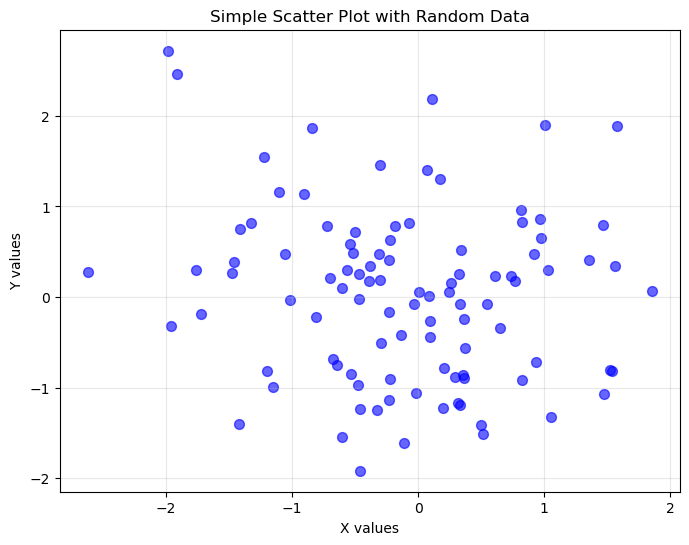

In [2]:
import matplotlib.pyplot as plt
import numpy as np

def create_scatter_plot(n_points=100, figsize=(8, 6), seed=42):
    """
    Create a simple scatter plot with random data.
    
    Parameters:
    - n_points: Number of data points to generate
    - figsize: Figure size as tuple (width, height)
    - seed: Random seed for reproducible results
    """
    # Generate random data for scatter plot
    np.random.seed(seed)
    x = np.random.randn(n_points)
    y = np.random.randn(n_points)
    
    # Create scatter plot
    plt.figure(figsize=figsize)
    plt.scatter(x, y, alpha=0.6, c='blue', s=50)
    plt.xlabel('X values')
    plt.ylabel('Y values')
    plt.title('Simple Scatter Plot with Random Data')
    plt.grid(True, alpha=0.3)
    plt.show()

# Example usage:
create_scatter_plot()



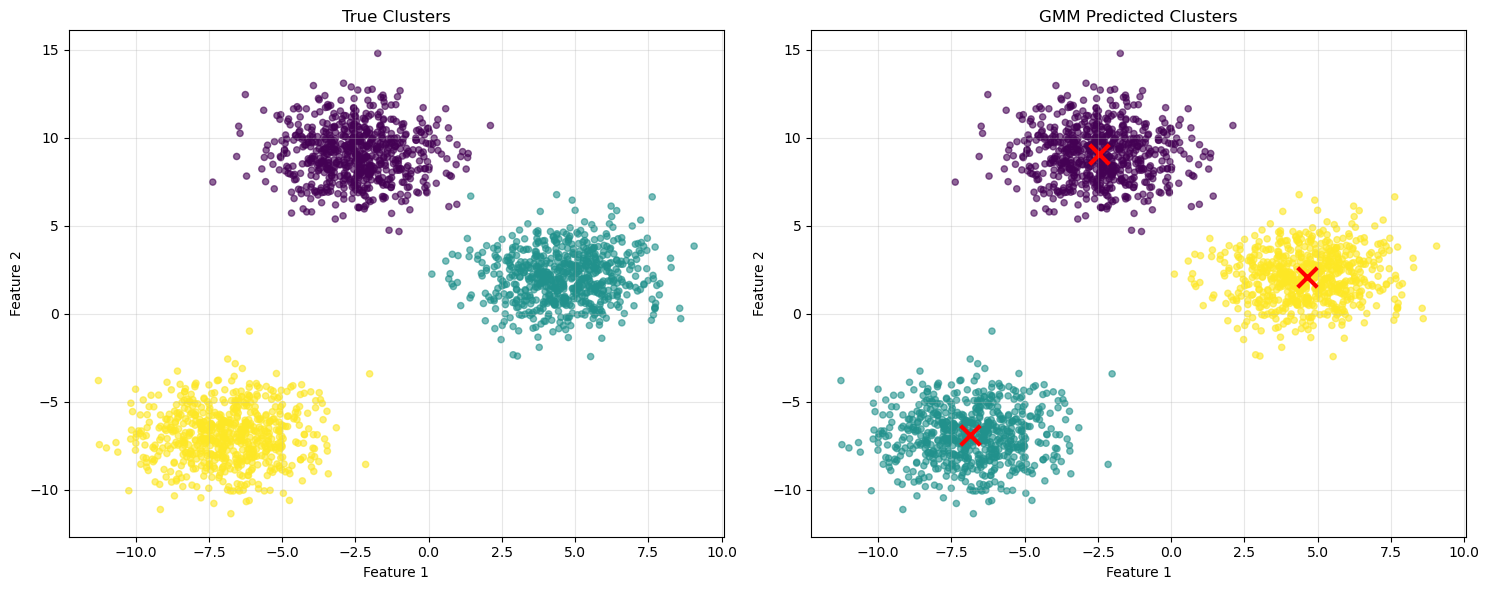

Number of components: 3
Log-likelihood: -4.74
AIC: 18982.17
BIC: 19077.38


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs

def create_gaussian_mixture_model(n_components=3, n_samples=2000, random_state=42):
    """
    Create and visualize a Gaussian Mixture Model.
    
    Parameters:
    - n_components: Number of Gaussian components in the mixture
    - n_samples: Number of data points to generate
    - random_state: Random seed for reproducible results
    """
    # Generate sample data with multiple clusters
    X, y_true = make_blobs(n_samples=n_samples, centers=n_components, 
                          cluster_std=1.5, random_state=random_state)
    
    # Fit Gaussian Mixture Model
    gmm = GaussianMixture(n_components=n_components, random_state=random_state)
    gmm.fit(X)
    
    # Predict cluster assignments
    y_pred = gmm.predict(X)
    
    # Create visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot original data with true clusters
    ax1.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', alpha=0.6, s=20)
    ax1.set_title('True Clusters')
    ax1.set_xlabel('Feature 1')
    ax1.set_ylabel('Feature 2')
    ax1.grid(True, alpha=0.3)
    
    # Plot GMM predictions
    ax2.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', alpha=0.6, s=20)
    ax2.set_title('GMM Predicted Clusters')
    ax2.set_xlabel('Feature 1')
    ax2.set_ylabel('Feature 2')
    ax2.grid(True, alpha=0.3)
    
    # Add cluster centers
    centers = gmm.means_
    ax2.scatter(centers[:, 0], centers[:, 1], c='red', marker='x', s=200, linewidths=3)
    
    plt.tight_layout()
    plt.show()
    
    # Print model information
    print(f"Number of components: {gmm.n_components}")
    print(f"Log-likelihood: {gmm.score(X):.2f}")
    print(f"AIC: {gmm.aic(X):.2f}")
    print(f"BIC: {gmm.bic(X):.2f}")
    
    return gmm, X, y_pred

# Example usage:
gmm_model, data, predictions = create_gaussian_mixture_model()


Generating synthetic DNA sequences...
Generated 800 DNA sequences
Sequence length: 150 nucleotides
Number of patterns: 4

First 5 sequences:
Pattern_1: ATGCATGCATGCTTGCATGCATGCATGCATGCATGCATGTACGCATGCAT...
Pattern_2: GCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCGAGC...
Pattern_3: TTAACCGGTTAACCGGTTAACCGGTTAAGCGGTTAACCGGTTAACGGGTG...
Pattern_4: CGATCGATAGATCGATCGATCGATCGATCGATCTATCAATCGATCTATCG...
Pattern_1: ATGCATCCACGCGTGCAAGCATGCATGCATGCATGCCTGCATGCATGCAT...


/var/folders/vd/69kmbq6s0s331vf09zfxgmh40000gn/T/ipykernel_11090/3974580295.py:98: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 0].boxplot([df[df['Pattern'] == pattern][nuc] for pattern in df['Pattern'].unique()],
/var/folders/vd/69kmbq6s0s331vf09zfxgmh40000gn/T/ipykernel_11090/3974580295.py:98: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 0].boxplot([df[df['Pattern'] == pattern][nuc] for pattern in df['Pattern'].unique()],
/var/folders/vd/69kmbq6s0s331vf09zfxgmh40000gn/T/ipykernel_11090/3974580295.py:98: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 0].boxplot([df[df['Pattern'] == pattern][n

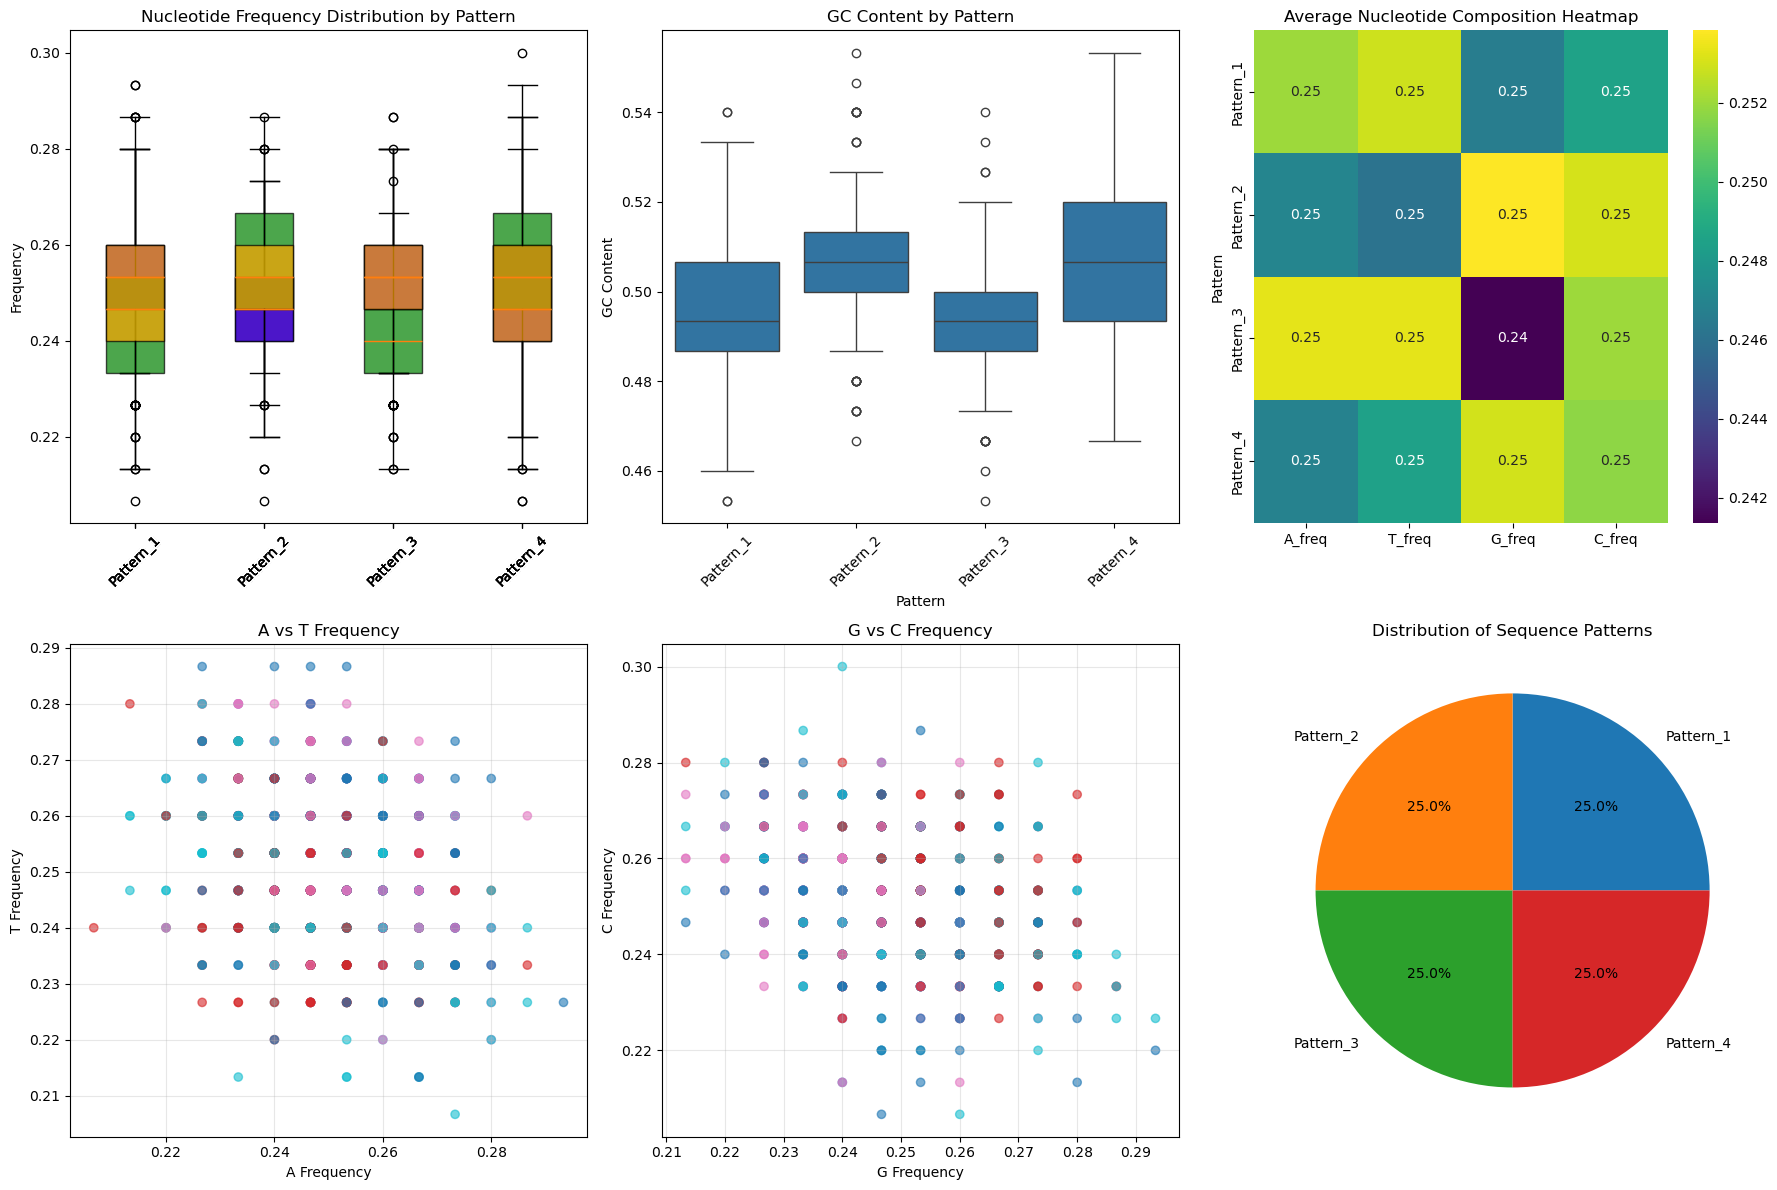


Dataset Summary:
       Sequence_ID      A_freq      T_freq      G_freq      C_freq  \
count     800.0000  800.000000  800.000000  800.000000  800.000000   
mean      399.5000    0.249808    0.250183    0.248692    0.251317   
std       231.0844    0.013469    0.013490    0.014449    0.013293   
min         0.0000    0.206667    0.206667    0.213333    0.206667   
25%       199.7500    0.240000    0.240000    0.240000    0.240000   
50%       399.5000    0.246667    0.246667    0.246667    0.253333   
75%       599.2500    0.260000    0.260000    0.260000    0.260000   
max       799.0000    0.293333    0.286667    0.293333    0.300000   

       GC_content  Length  
count  800.000000   800.0  
mean     0.500008   150.0  
std      0.016328     0.0  
min      0.453333   150.0  
25%      0.486667   150.0  
50%      0.500000   150.0  
75%      0.513333   150.0  
max      0.553333   150.0  

Pattern-wise Statistics:
          GC_content        A_freq T_freq G_freq C_freq
                m

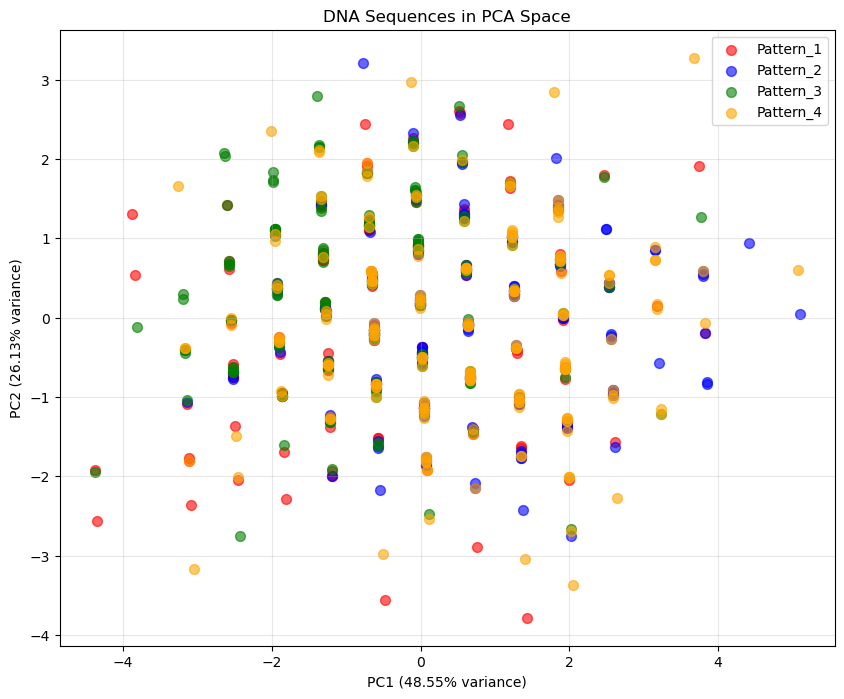

PCA explained variance: 74.68%


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import random

def generate_dna_sequences(n_sequences=1000, seq_length=100, mutation_rate=0.05):
    """
    Generate synthetic DNA sequences with different patterns and mutations
    """
    # Define nucleotides
    nucleotides = ['A', 'T', 'G', 'C']
    
    # Create different sequence patterns/motifs
    motifs = [
        'ATGCATGC',  # Pattern 1
        'GCTAGCTA',  # Pattern 2
        'TTAACCGG',  # Pattern 3
        'CGATCGAT'   # Pattern 4
    ]
    
    sequences = []
    labels = []
    
    for i in range(n_sequences):
        # Choose a motif pattern
        motif_idx = i % len(motifs)
        base_motif = motifs[motif_idx]
        
        # Create sequence by repeating and extending motif
        sequence = ''
        while len(sequence) < seq_length:
            sequence += base_motif
        sequence = sequence[:seq_length]
        
        # Add random mutations
        sequence_list = list(sequence)
        n_mutations = int(len(sequence) * mutation_rate)
        
        for _ in range(n_mutations):
            pos = random.randint(0, len(sequence_list) - 1)
            sequence_list[pos] = random.choice(nucleotides)
        
        sequences.append(''.join(sequence_list))
        labels.append(f'Pattern_{motif_idx + 1}')
    
    return sequences, labels

def analyze_dna_composition(sequences, labels):
    """
    Analyze nucleotide composition and create visualizations
    """
    # Calculate nucleotide frequencies for each sequence
    composition_data = []
    
    for seq, label in zip(sequences, labels):
        counts = Counter(seq)
        total = len(seq)
        composition = {
            'Sequence_ID': len(composition_data),
            'Pattern': label,
            'A_freq': counts.get('A', 0) / total,
            'T_freq': counts.get('T', 0) / total,
            'G_freq': counts.get('G', 0) / total,
            'C_freq': counts.get('C', 0) / total,
            'GC_content': (counts.get('G', 0) + counts.get('C', 0)) / total,
            'Length': len(seq)
        }
        composition_data.append(composition)
    
    return pd.DataFrame(composition_data)

# Generate synthetic DNA dataset
print("Generating synthetic DNA sequences...")
sequences, labels = generate_dna_sequences(n_sequences=800, seq_length=150, mutation_rate=0.08)

# Analyze composition
df = analyze_dna_composition(sequences, labels)

print(f"Generated {len(sequences)} DNA sequences")
print(f"Sequence length: {len(sequences[0])} nucleotides")
print(f"Number of patterns: {len(set(labels))}")

# Display first few sequences
print("\nFirst 5 sequences:")
for i in range(5):
    print(f"{labels[i]}: {sequences[i][:50]}...")

# Create comprehensive visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Nucleotide frequency distribution by pattern
nucleotides = ['A_freq', 'T_freq', 'G_freq', 'C_freq']
colors = ['red', 'blue', 'green', 'orange']

for i, (nuc, color) in enumerate(zip(nucleotides, colors)):
    axes[0, 0].boxplot([df[df['Pattern'] == pattern][nuc] for pattern in df['Pattern'].unique()], 
                       labels=df['Pattern'].unique(), patch_artist=True,
                       boxprops=dict(facecolor=color, alpha=0.7))
axes[0, 0].set_title('Nucleotide Frequency Distribution by Pattern')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. GC Content distribution
sns.boxplot(data=df, x='Pattern', y='GC_content', ax=axes[0, 1])
axes[0, 1].set_title('GC Content by Pattern')
axes[0, 1].set_ylabel('GC Content')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Heatmap of average nucleotide composition
composition_matrix = df.groupby('Pattern')[['A_freq', 'T_freq', 'G_freq', 'C_freq']].mean()
sns.heatmap(composition_matrix, annot=True, cmap='viridis', ax=axes[0, 2])
axes[0, 2].set_title('Average Nucleotide Composition Heatmap')

# 4. Scatter plot: A vs T frequency
scatter = axes[1, 0].scatter(df['A_freq'], df['T_freq'], c=df['Pattern'].astype('category').cat.codes, 
                            cmap='tab10', alpha=0.6)
axes[1, 0].set_xlabel('A Frequency')
axes[1, 0].set_ylabel('T Frequency')
axes[1, 0].set_title('A vs T Frequency')
axes[1, 0].grid(True, alpha=0.3)

# 5. Scatter plot: G vs C frequency
scatter2 = axes[1, 1].scatter(df['G_freq'], df['C_freq'], c=df['Pattern'].astype('category').cat.codes, 
                             cmap='tab10', alpha=0.6)
axes[1, 1].set_xlabel('G Frequency')
axes[1, 1].set_ylabel('C Frequency')
axes[1, 1].set_title('G vs C Frequency')
axes[1, 1].grid(True, alpha=0.3)

# 6. Pattern distribution
pattern_counts = df['Pattern'].value_counts()
axes[1, 2].pie(pattern_counts.values, labels=pattern_counts.index, autopct='%1.1f%%')
axes[1, 2].set_title('Distribution of Sequence Patterns')

plt.tight_layout()
plt.show()

# Display summary statistics
print("\nDataset Summary:")
print(df.describe())

print("\nPattern-wise Statistics:")
print(df.groupby('Pattern').agg({
    'GC_content': ['mean', 'std'],
    'A_freq': 'mean',
    'T_freq': 'mean',
    'G_freq': 'mean',
    'C_freq': 'mean'
}).round(3))

# Save dataset for further analysis
print(f"\nDataset shape: {df.shape}")
print("Dataset ready for machine learning experiments!")

# Example: Simple clustering visualization
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Prepare features for clustering
features = df[['A_freq', 'T_freq', 'G_freq', 'C_freq', 'GC_content']].values
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Apply PCA for visualization
pca = PCA(n_components=2)
features_pca = pca.fit_transform(features_scaled)

# Plot PCA results
plt.figure(figsize=(10, 8))
colors = ['red', 'blue', 'green', 'orange']
for i, pattern in enumerate(df['Pattern'].unique()):
    mask = df['Pattern'] == pattern
    plt.scatter(features_pca[mask, 0], features_pca[mask, 1], 
               c=colors[i], label=pattern, alpha=0.6, s=50)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('DNA Sequences in PCA Space')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.2%}")
